In [1]:
import os
from collections import Counter, defaultdict
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the datasets form the folder data which contains the data realted to the files.

In [2]:
DATA_DIR = "."  # Change this to your data directory
TRAIN_FASTA = os.path.join(DATA_DIR, "train_sequences.fasta")
TEST_FASTA = os.path.join(DATA_DIR, "test_superset.fasta")
TRAIN_TERMS = os.path.join(DATA_DIR, "train_terms.tsv")
GO_OBO = os.path.join(DATA_DIR, "go-basic.obo")

exploring training sequences:

In [11]:

from Bio import SeqIO
import os

print("\n ANALYZING TRAINING SEQUENCES...")

TRAIN_FASTA = r"D:\CAFA project\data\train_sequences.fasta"

train_sequences = {}
seq_lengths = []

for record in SeqIO.parse(TRAIN_FASTA, "fasta"):
    # Extract UniProt accession
    protein_id = record.id.split("|")[1]
    sequence = str(record.seq)

    train_sequences[protein_id] = sequence
    seq_lengths.append(len(sequence))

print(f" Total training proteins: {len(train_sequences)}")
print(f" Sequence length - Min: {min(seq_lengths)}, Max: {max(seq_lengths)}, Mean: {sum(seq_lengths)/len(seq_lengths):.1f}")
print(f" Example protein ID: {list(train_sequences.keys())[0]}")
print(f" Example sequence (first 50 aa): {list(train_sequences.values())[0][:50]}...")



 ANALYZING TRAINING SEQUENCES...
 Total training proteins: 82404
 Sequence length - Min: 3, Max: 35213, Mean: 525.8
 Example protein ID: A0A0C5B5G6
 Example sequence (first 50 aa): MRWQEMGYIFYPRKLR...


In [12]:
print("\n ANALYZING TEST SEQUENCES...")

test_sequences = {}
test_seq_lengths = []
TEST_FASTA = r"D:\CAFA project\data\testsuperset.fasta"
try:
    for record in SeqIO.parse(TEST_FASTA, "fasta"):
        protein_id = record.id
        sequence = str(record.seq)
        test_sequences[protein_id] = sequence
        test_seq_lengths.append(len(sequence))
    
    print(f" Total test proteins: {len(test_sequences)}")
    print(f" Sequence length - Min: {min(test_seq_lengths)}, Max: {max(test_seq_lengths)}, Mean: {sum(test_seq_lengths)/len(test_seq_lengths):.1f}")
    
except FileNotFoundError:
    print(f" File not found: {TEST_FASTA}")


 ANALYZING TEST SEQUENCES...
 Total test proteins: 224309
 Sequence length - Min: 2, Max: 35213, Mean: 429.2


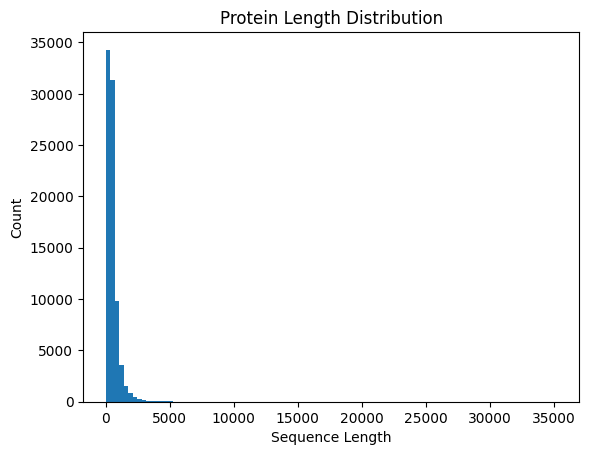

In [13]:
import matplotlib.pyplot as plt

plt.hist(seq_lengths, bins=100)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Protein Length Distribution")
plt.show()


In [ ]:
print("\n ANALYZING TRAINING LABELS...")
TRAIN_TERMS = r"D:\CAFA project\data\train_terms.tsv"


try:
    # Load training terms
    df_terms = pd.read_csv(TRAIN_TERMS, sep='\t', header=None, 
                           names=['protein_id', 'go_term', 'ontology'])
    
    print(f"✓ Total annotations: {len(df_terms)}")
    print(f"✓ Unique proteins with labels: {df_terms['protein_id'].nunique()}")
    print(f"✓ Unique GO terms: {df_terms['go_term'].nunique()}")
    
    # Analyze by ontology
    print("\n   Distribution by Ontology:")
    ontology_counts = df_terms['ontology'].value_counts()
    for ont, count in ontology_counts.items():
        unique_terms = df_terms[df_terms['ontology'] == ont]['go_term'].nunique()
        print(f"   - {ont}: {count} annotations, {unique_terms} unique terms")
    
    # Annotations per protein
    annotations_per_protein = df_terms.groupby('protein_id').size()
    print(f"\n   Annotations per protein - Min: {annotations_per_protein.min()}, "
          f"Max: {annotations_per_protein.max()}, Mean: {annotations_per_protein.mean():.1f}")
    
    # Most common GO terms
    print("\n   Top 10 most common GO terms:")
    top_terms = df_terms['go_term'].value_counts().head(10)
    for term, count in top_terms.items():
        ont = df_terms[df_terms['go_term'] == term]['ontology'].iloc[0]
        print(f"   - {term} ({ont}): {count} proteins")
    
    # Save summary
    summary = {
        'train_proteins': len(train_sequences),
        'test_proteins': len(test_sequences),
        'total_annotations': len(df_terms),
        'unique_go_terms': df_terms['go_term'].nunique(),
        'ontology_distribution': ontology_counts.to_dict()
    }
    
    print("\n" + "=" * 80)
    print("SUMMARY:")
    for key, value in summary.items():
        print(f"  {key}: {value}")
    
except FileNotFoundError:
    print(f" File not found: {TRAIN_TERMS}")


 ANALYZING TRAINING LABELS...
✓ Total annotations: 537028
✓ Unique proteins with labels: 82405
✓ Unique GO terms: 26126

   Distribution by Ontology:
   - P: 250805 annotations, 16858 unique terms
   - C: 157770 annotations, 2651 unique terms
   - F: 128452 annotations, 6616 unique terms
   - aspect: 1 annotations, 1 unique terms

   Annotations per protein - Min: 1, Max: 233, Mean: 6.5

   Top 10 most common GO terms:
   - GO:0005515 (F): 33713 proteins
   - GO:0005634 (C): 13283 proteins
   - GO:0005829 (C): 13040 proteins
   - GO:0005886 (C): 10150 proteins
   - GO:0005737 (C): 9442 proteins
   - GO:0005739 (C): 5807 proteins
   - GO:0005654 (C): 5065 proteins
   - GO:0016020 (C): 3563 proteins
   - GO:0042802 (F): 3547 proteins
   - GO:0005576 (C): 3241 proteins

SUMMARY:
  train_proteins: 82404
  test_proteins: 224309
  total_annotations: 537028
  unique_go_terms: 26126
  ontology_distribution: {'P': 250805, 'C': 157770, 'F': 128452, 'aspect': 1}



  GENERATING VISUALIZATIONS...
 Saved visualization to 'cafa6_data_exploration.png'

EXPLORATION COMPLETE!
Next steps: Run Step 2 - Feature Extraction (Protein Embeddings)


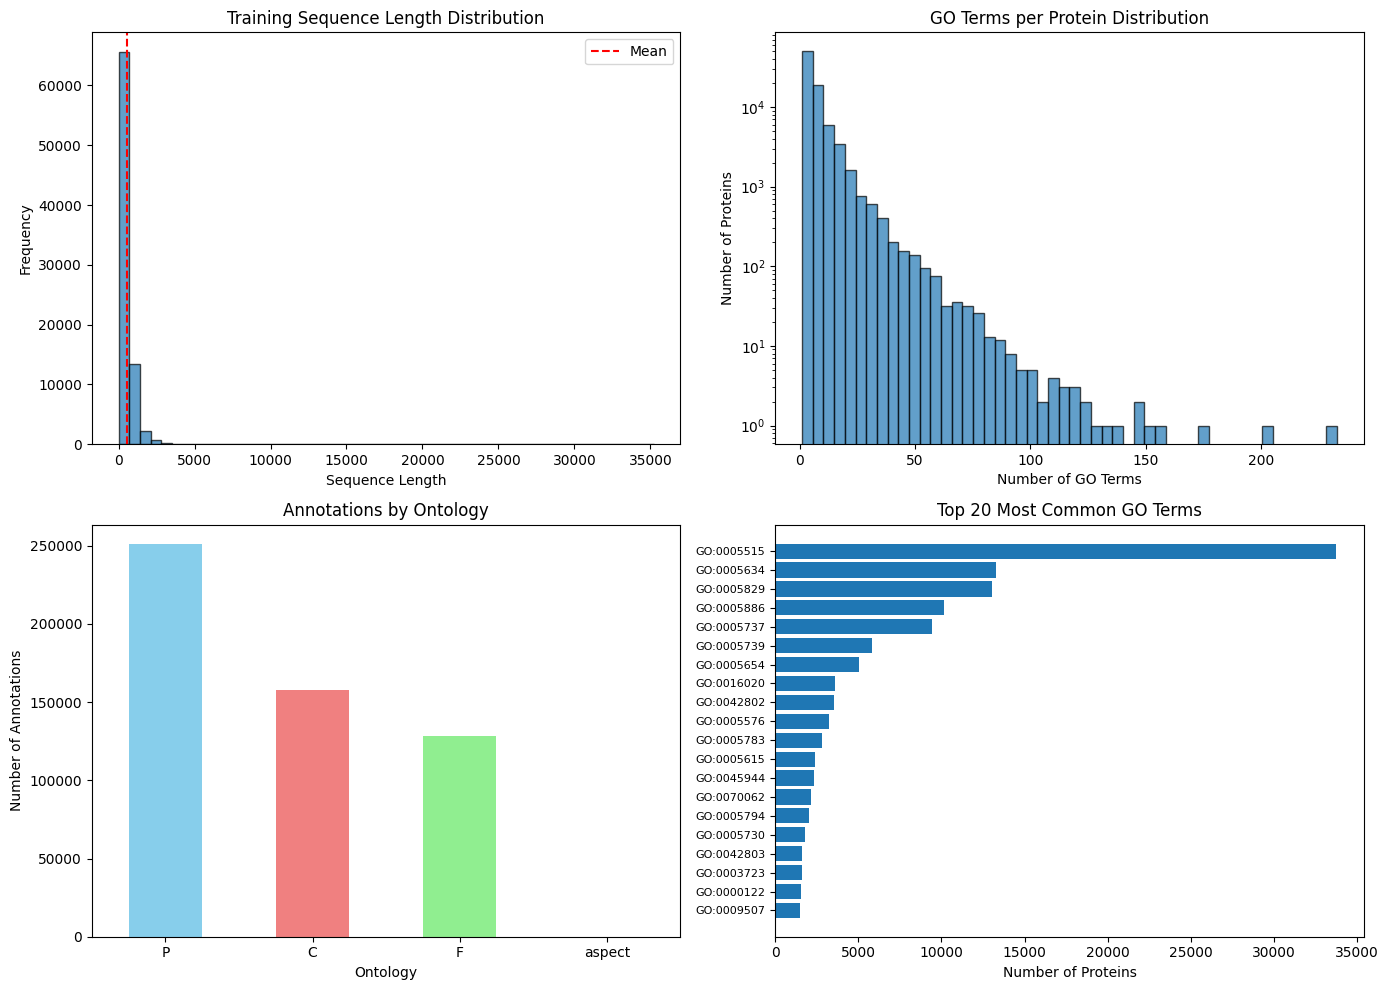

In [16]:
print("\n  GENERATING VISUALIZATIONS...")

try:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Sequence length distribution (training)
    axes[0, 0].hist(seq_lengths, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Sequence Length')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Training Sequence Length Distribution')
    axes[0, 0].axvline(sum(seq_lengths)/len(seq_lengths), color='red', 
                       linestyle='--', label='Mean')
    axes[0, 0].legend()
    
    # Plot 2: Annotations per protein
    axes[0, 1].hist(annotations_per_protein, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Number of GO Terms')
    axes[0, 1].set_ylabel('Number of Proteins')
    axes[0, 1].set_title('GO Terms per Protein Distribution')
    axes[0, 1].set_yscale('log')
    
    # Plot 3: Ontology distribution
    ontology_counts.plot(kind='bar', ax=axes[1, 0], color=['skyblue', 'lightcoral', 'lightgreen'])
    axes[1, 0].set_xlabel('Ontology')
    axes[1, 0].set_ylabel('Number of Annotations')
    axes[1, 0].set_title('Annotations by Ontology')
    axes[1, 0].tick_params(axis='x', rotation=0)
    
    # Plot 4: Top 20 GO terms
    top_20_terms = df_terms['go_term'].value_counts().head(20)
    axes[1, 1].barh(range(len(top_20_terms)), top_20_terms.values)
    axes[1, 1].set_yticks(range(len(top_20_terms)))
    axes[1, 1].set_yticklabels(top_20_terms.index, fontsize=8)
    axes[1, 1].set_xlabel('Number of Proteins')
    axes[1, 1].set_title('Top 20 Most Common GO Terms')
    axes[1, 1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('cafa6_data_exploration.png', dpi=300, bbox_inches='tight')
    print(" Saved visualization to 'cafa6_data_exploration.png'")
    
except Exception as e:
    print(f" Could not generate visualizations: {e}")

print("\n" + "=" * 80)
print("EXPLORATION COMPLETE!")
print("Next steps: Run Step 2 - Feature Extraction (Protein Embeddings)")
print("=" * 80)

| Aspect          | Description                                                                  |
| --------------- | ---------------------------------------------------------------------------- |
| Plot shows      | Distribution of amino-acid sequence lengths of training proteins             |
| Shape           | Highly right-skewed with a long tail                                         |
| Minimum length  | Very short peptides (≈ 2–3 amino acids)                                      |
| Maximum length  | Extremely long proteins (up to ~35,000 amino acids)                          |
| Mean length     | ~526 amino acids (not representative due to skewness)                        |
| Key insight     | Most proteins are relatively short; few very long proteins dominate the tail |
| Modeling impact | Requires sequence truncation or chunking for deep learning models            |


| Aspect          | Description                                                         |
| --------------- | ------------------------------------------------------------------- |
| Plot shows      | Number of GO annotations assigned per protein                       |
| Scale           | Logarithmic (to visualize rare high-count cases)                    |
| Typical range   | 1–10 GO terms for most proteins                                     |
| Outliers        | Some proteins have >100 GO terms                                    |
| Distribution    | Heavy-tailed, highly imbalanced                                     |
| Key insight     | CAFA-6 is a true multi-label classification problem                 |
| Modeling impact | Requires multi-label loss functions and careful threshold selection |


| Ontology        | Meaning                                                   | Relative Count      | Interpretation                         |
| --------------- | --------------------------------------------------------- | ------------------- | -------------------------------------- |
| **P**           | Biological Process                                        | Highest             | Broad, complex functional descriptions |
| **C**           | Cellular Component                                        | Medium              | Subcellular localization information   |
| **F**           | Molecular Function                                        | Lowest              | Specific biochemical activities        |
| Overall trend   | P > C > F                                                 | Uneven distribution | Ontology imbalance exists              |
| Modeling impact | Ontology-specific models or heads may improve performance |                     |                                        |


| Aspect            | Description                                                           |
| ----------------- | --------------------------------------------------------------------- |
| Plot shows        | Most frequently annotated GO terms in the training set                |
| Frequency pattern | Few GO terms appear in tens of thousands of proteins                  |
| Distribution type | Power-law / long-tail                                                 |
| Common terms      | General functions (e.g., binding, cellular location)                  |
| Rare terms        | Highly specific biological functions                                  |
| Key insight       | Strong label frequency imbalance                                      |
| Modeling impact   | Risk of bias toward common GO terms; rare terms are harder to predict |
